In [2]:
# libraries and imports
import sys
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('../matplotlib.mplstyle')

# Open Access status in time
In this study, we will get data from [OpenAlex](www.openalex.org) to extract data on how the Open Access status of publications has evolved in the past 10 years.

In [3]:
# first, we define a handy function that will help us perform queries to the OpenAlex APIs.
def send_query(url, params, print_query=False):

        # perform the request using the specified URL and parameters
        r = requests.get(url, params)

        if print_query:
            print(r.request.url)

        # check the status code of the request
        if r.status_code != 200:

            if r.status_code == 414:
                raise ValueError("""API error: {}""".format(r.reason))
            else:
                import ast
                err = ast.literal_eval(r.text)
                raise ValueError("""API error:\n\tERROR  :  {error}\n\tMESSAGE:  {message}""".format(**err))
        else:

            # if there is no error return the JSON object for the results
            return r.json()

In [7]:
# then, we obtain the data, starting from MIN_YEAR and ending at MAX_YEAR, both included
MIN_YEAR = 2015
MAX_YEAR = 2025
OA_API_URL = 'https://api.openalex.org'
oa_status_year = {}
for year in range(MIN_YEAR, MAX_YEAR+1):
    # build the URL for the request
    URL = f'{OA_API_URL}/works'
    tmp = send_query(
        URL,
        params={'filter':f'type:article,publication_year:{year}', 'group_by':'oa_status'})['group_by']
    oa_status_year[year] = pd.DataFrame(tmp).set_index('key')['count'].rename('npapers')

In [8]:
oa_status_year = pd.DataFrame(oa_status_year)
oa_status_year.sum()

2015    7207568
2016    7246654
2017    6853936
2018    6810353
2019    7087018
2020    7227151
2021    6644701
2022    6043447
2023    6322328
2024    6655393
2025    7691611
dtype: int64

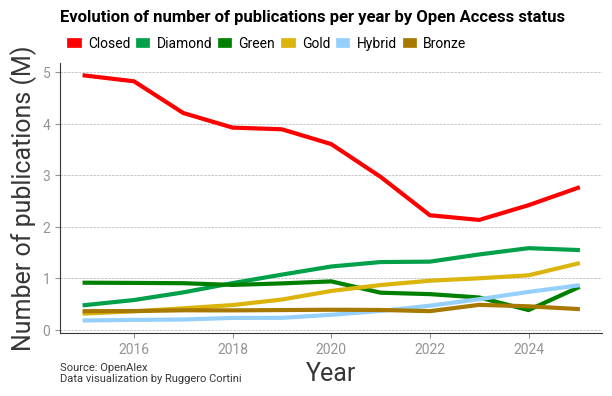

In [9]:
# prepare data
plot_df = (oa_status_year/1e6).T
order_status = plot_df.sum(axis=0).sort_values(ascending=False).index
plot_df = plot_df[order_status]

# init figure
fig, ax = plt.subplots(figsize=(7,3.5))

# color mapping
colors = {
    'closed':'red',
    'gold':'xkcd:gold',
    'bronze':'xkcd:bronze',
    'green':'green',
    'hybrid':'xkcd:light blue',
    'diamond':'xkcd:emerald'
}

for col in plot_df.columns:
    plot_df[col].plot(
        color=colors[col],
        linewidth=3,
        label=col.capitalize(),
        ax=ax
    )

ax.set_xlabel('Year')
ax.set_ylabel('Number of publications (M)')

# legend
leg = ax.legend(title='', ncols=6, loc='lower left', bbox_to_anchor=(0,1), handlelength=0.3, columnspacing=0.8)
for legobj in leg.legend_handles:
    legobj.set_linewidth(7.0)

ax.set_title('Evolution of number of publications per year by Open Access status', loc='left', pad=30, fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', linewidth=0.5)
ax.text(2014.5, -1., "Source: OpenAlex\nData visualization by Ruggero Cortini", color='xkcd:dark grey',fontsize=8)

fig.savefig('n_year.png', dpi=600, bbox_inches='tight')